# Array topology sweep — escenas aleatorias 3D (arreglo sobre mesa)

Compara las **3 topologías** de arreglo (2D, **misma superficie ocupada**, mismo `M`)
bajo un **muestreo aleatorio de escenas 3D**, para ver qué topología es más robusta a
posiciones arbitrarias de fuente e interferencia. Se barren además **M = 6, 8 y 12**
micrófonos.

**Cambios respecto de la versión anterior** (a partir de las pruebas auxiliares en
`tests/array/`):

- El arreglo circular es ahora la **UCA con micrófono central**
  (`circular_center`): un micrófono en el centro y los `M-1` restantes en el anillo —
  el central **cuenta dentro de `M`**, así que no gasta sensores extra. La prueba
  `array_circular_center.ipynb` mostró que mejora a NM-MVDR: la referencia del filtro
  queda a 7,5 cm de todos los micrófonos en vez de a 15 cm del opuesto.
- Se quitó la **espiral** (quedaba siempre atrás y su espaciado mínimo submilimétrico
  la hacía poco realizable) y el **MVDR oracle**: el único procesador es `NM_MVDR`,
  el sistema real.

**Superficie equivalente:** la referencia es el **arreglo circular (UCA) de
`DIAMETER = 15 cm`**, que ocupa `A_ref = π·(D/2)² ≈ 176,7 cm²`. `circular_center` y
`concentric` quedan inscriptas en ese círculo; la **grilla rectangular ya NO** — se
liberó la restricción de inscripción y en su lugar se le impone **misma área**
(`generate_grid_array_coords_area`, `area_mode='span'`: el rectángulo que abarcan los
micrófonos extremos tiene área `A_ref`). Eso permite **filas ≠ columnas**
(6 → 2×3, 8 → 2×4, 12 → 3×4) y amplía el rango de `M` utilizables, en vez de exigir
una grilla `n×n` con `n` impar.

**Bafle (mesa/piso):** el arreglo es planar en XY y se apoya **flush sobre el piso**
(`BAFFLE_HEIGHT` ≈ 0.5 cm), que actúa de bafle horizontal — un dispositivo apoyado
sobre una mesa. Su broadside mira hacia arriba. El material del piso no es rígido
(mismo α del RT60), así que el bafle es **parcial**.

**Escenas aleatorias (pares target–interferencia 1:1):**

- **Target**: **toroide apoyado sobre el piso**, concéntrico al arreglo. Modela la
  condición de uso real: locutores *alrededor* del dispositivo con la boca a
  ~**50 cm** por encima del plano del arreglo. El tubo es tangente al piso, con el
  círculo generador a `TORUS_R_TUBE` de altura → alturas 0–0.9 m (media 0.45 m),
  distancia horizontal 0.65–1.55 m, **elevación ≈ 2–45°**. Reemplaza al domo, que
  ponía fuentes en el cenit y pegadas al plano.
- **Interferencia**: **uniforme en el volumen de la sala** — se sortea el *punto*
  dentro de la sala útil (paredes menos `WALL_MARGIN`, siempre sobre el bafle) y de
  ahí salen azimut/elevación/distancia. Muestrear los tres ángulos por separado
  dejaba las fuentes en un cascarón alrededor del arreglo y las esquinas vacías.
- Cada escena empareja **un** target con **una** interferencia. Se generan `N_SCENES`
  geometrías, reutilizadas en las 3 salas para aislar el efecto de la reverberación.

**Micrófono de referencia:** los beamformers de la familia Souden (**NM-MVDR**,
Souden-oracle) proyectan su salida sobre **un** micrófono, que fija el *punto de
escucha* del filtro espacial. Se usa el **más cercano al centro geométrico** del
arreglo (`select_reference_mic`), que minimiza la distancia al resto de los micrófonos.
El motor lo usa **también** como canal del baseline y de las referencias, así
`Delta_tot` mide la mejora sobre el mismo canal que el filtro reconstruye
(`ref_mic_mode='centroid'`).

**Salas / RT60** realistas (oficina 0.3 s · aula 0.5 s · salón 0.8 s). El arreglo se
**centra** en cada sala para que el toroide entre completo.

**Algoritmo:** sólo `NM_MVDR` (máscara DTLN + Souden), que es el sistema real. Se
eliminaron `DS` y `SOUDEN_ORACLE_SCM`: la pregunta ya no es cuánto techo hay, sino qué
geometría le conviene al sistema que se va a implementar.

**Dataset:** cada fila guarda además la **elevación**, el azimut y la altura reales
del target y de la interferencia (`source_elevation_deg`, …), para graficar cualquier
métrica en función del ángulo de altura.

**Tamaño:** 3 salas × `N_SCENES` escenas × 3 topologías × 3 valores de `M` × 1 algoritmo.
El DTLN mono (Node 4.5) y el post-filtro DTLN (Node 6) quedan **apagados** para acelerar.

**Orden:** Setup → Config → **Geometrías** → **Escena 3D (pre-vuelo)** → Run → Resultados.


## Setup

In [1]:
import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO_ROOT = "/home/matias/Documents/Tesis/Vision-Aided-Beamformer"
SRC = os.path.join(REPO_ROOT, "src")
for p in (REPO_ROOT, SRC):
    if p not in sys.path:
        sys.path.insert(0, p)
os.chdir(SRC)

from evaluation.full_benchmark_test_dtln import run_grid_search
from evaluation.bf_wrappers import DS, SOUDEN_ORACLE_SCM, NM_MVDR
from beamforming.array.geometry import (generate_array_coords, place_spherical,
                                        max_distance_in_room, select_reference_mic,
                                        sample_torus_specs, sample_box_uniform_specs)
print('[*] Setup OK')


I0000 00:00:1787930483.248130  416191 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787930483.248494  416191 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1787930483.276234  416191 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1787930484.174032  416191 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_E

[*] Setup OK


## Config — arreglo, salas y generador aleatorio de escenas

Lo *físico* se define acá.

**Arreglo.** La superficie de referencia sale del **círculo de `DIAMETER = 15 cm`**
(`A_ref = π·(D/2)²`). Todas las topologías ocupan esa misma superficie; la grilla lo
hace **por área** (rectángulo `filas × columnas`, no inscripto) y el resto por
inscripción. Se barre `M ∈ {6, 8, 12}`. El circular es la variante **con micrófono
central** (`circular_center`): el central cuenta dentro de `M`, así que las tres
topologías usan el mismo presupuesto de sensores.

**Micrófono de referencia** (`REF_MIC_MODE = 'centroid'`): el más cercano al centro
geométrico del arreglo. Es el canal sobre el que proyectan los beamformers de Souden
(NM-MVDR incluido) **y** el canal contra el que se calculan baseline y referencias, de
modo que ambos vivan en el mismo punto de escucha.

**Bafle.** El arreglo se apoya **flush sobre el piso** (`BAFFLE_HEIGHT`), que hace de
bafle horizontal; su broadside mira hacia arriba.

**Escenas** (RNG sembrado, reproducible). Cada escena es un par `(target, interferencia)`:

- **Target** — **toroide apoyado sobre el piso**: círculo generador de radio
  `TORUS_R_MAJOR` a la altura `TORUS_R_TUBE`, tubo de radio `TORUS_R_TUBE` tangente al
  piso. Muestreo uniforme en el **volumen** del tubo (corrección por el factor
  `ρ/(R+r)`). Da locutores alrededor del dispositivo, con la boca ~50 cm sobre el plano
  del arreglo, y **elevaciones acotadas y realistas** (≈ 2–45°) en vez del domo completo.
- **Interferencia** — **uniforme en el volumen de la sala** (`sample_box_uniform_specs`):
  el punto se sortea dentro de la caja útil y recién después se convierte a
  (azimut, elevación, distancia). La caja es la **intersección** de las tres salas en
  coordenadas relativas al centro del arreglo, así la misma posición vale en las tres
  y el motor **no recorta nada** por pared. Densidad constante por volumen ⇒ la
  mayoría cae lejos y a baja elevación (la sala es mucho más ancha que alta).

Las `N_SCENES` geometrías se generan **una vez** (independientes de la sala y de `M`) y
se reutilizan en las 3 salas y en todas las topologías/M, así la comparación ve
exactamente las mismas direcciones y distancias.


In [2]:
# --------------------------- ARREGLO (barrido) ---------------------------
# SUPERFICIE DE REFERENCIA: el arreglo CIRCULAR (UCA) de DIAMETER. Su area
# A_REF = pi*(D/2)^2 es la superficie que deben ocupar TODAS las topologias.
M_LIST     = [6, 8, 12]          # microfonos (eje de barrido)
DIAMETER   = 0.15                # [m] diametro del circulo de referencia
A_REF      = np.pi * (DIAMETER / 2.0) ** 2      # [m^2] superficie equivalente
# 'circular_center' = UCA con un microfono en el CENTRO (contado dentro de M): la
# referencia del beamformer queda a D/2 de TODOS los micros en vez de a D del opuesto.
# Reemplaza a 'circular' (ver tests/array/array_circular_center.ipynb). Se saco
# 'spiral': quedaba ultima y su d_min submilimetrico no es realizable.
TOPOLOGIES = ['circular_center', 'grid', 'concentric']

# GRILLA RECTANGULAR: equivalente POR AREA, ya NO inscripta en el circulo.
#   'span' -> el rectangulo que abarcan los micros EXTREMOS tiene area A_REF
#             (mismo "plato" fisico que el circulo). Al no exigir n x n, admite
#             filas != columnas: 6 -> 2x3, 8 -> 2x4, 12 -> 3x4.
#   'cell' -> cada micro ocupa A_REF/M (misma DENSIDAD que el circulo, footprint
#             menor). Alternativa para contrastar.
GRID_AREA_MODE  = 'span'
TOPOLOGY_KWARGS = {'grid': {'area_mode': GRID_AREA_MODE}}   # {topologia -> kwargs}

def topo_kwargs_for(topology):
    """Mismos kwargs que le pasa el motor a generate_array_coords (para replicar
    la geometria exacta en los graficos de pre-vuelo)."""
    return dict(TOPOLOGY_KWARGS.get(topology, {}))

# --------------------- MICROFONO DE REFERENCIA ------------------------
# Los beamformers de Souden (NM-MVDR, Souden-oracle) proyectan la salida sobre UN
# microfono: ese canal es el PUNTO DE ESCUCHA del filtro (estima la voz tal como
# llega ahi). Se elige el mas cercano al CENTRO GEOMETRICO del arreglo, que
# minimiza la distancia -y por lo tanto la dispersion de caminos acusticos- hacia
# el resto de los micros. El motor lo usa TAMBIEN para el baseline y las
# referencias, para que Delta_tot no mezcle dos puntos de escucha distintos.
# (El default historico, M//2, cae en un lugar arbitrario que depende de como
# cada generador ENUMERA sus micros: para la UCA es el diametralmente opuesto al 0.)
REF_MIC_MODE = 'centroid'

# --------------------------- SALAS / RT60 -----------------------------
ROOM_PROFILES = {
    0.30: np.array([6.0, 7.0, 2.8]),   # oficina
    0.50: np.array([7.0, 8.0, 3.0]),   # aula
    0.80: np.array([9.0, 11.0, 3.5]),  # salon
}

# --------- BAFLE HORIZONTAL: arreglo apoyado (flush) sobre el PISO ---------
# El arreglo es planar en XY y se apoya flush sobre el piso (limite z=0 de la
# ShoeBox), que actua de bafle horizontal: el dispositivo sobre una mesa. Su
# broadside apunta hacia ARRIBA (+Z) y las fuentes viven por encima. El material
# del piso NO es rigido (mismo alpha del RT60) => bafle PARCIAL, compromiso asumido.
BAFFLE_HEIGHT = 0.005   # 0.5 cm sobre el piso (flush)

WALL_MARGIN = 0.3   # [m] aire minimo contra cada pared para cualquier fuente

# El toroide de targets llega hasta TORUS_R_MAJOR + TORUS_R_TUBE de radio horizontal:
# el arreglo se centra en cada sala para que entre completo (360 de azimut).
ARRAY_CENTER_MAP = {
    0.30: np.array([3.0, 2.5, BAFFLE_HEIGHT]),
    0.50: np.array([3.5, 3.0, BAFFLE_HEIGHT]),
    0.80: np.array([4.5, 3.5, BAFFLE_HEIGHT]),
}

# =========== GENERADOR ALEATORIO DE ESCENAS (target + interf 1:1) ==========
N_SCENES = 60          # escenas aleatorias (mismas geometrias en las 3 salas)
RNG_SEED = 2026        # reproducible

# --- TARGET: TOROIDE APOYADO SOBRE EL PISO (condicion de uso "de mesa") ---
# El dispositivo esta sobre una mesa y los locutores hablan ALREDEDOR, con la boca
# ~50 cm por encima del plano del arreglo. Eso no es un domo (que pone fuentes en
# el cenit y otras pegadas al plano) sino un ANILLO con espesor: un toroide cuyo
# tubo es TANGENTE al piso, con el circulo generador a TORUS_R_TUBE de altura.
#   altura de la fuente : TORUS_Z_MIN .. 2*TORUS_R_TUBE, centrada en TORUS_R_TUBE
#   distancia horizontal: TORUS_R_MAJOR +/- TORUS_R_TUBE
#   elevacion resultante: acotada y realista (se guarda por escena en el dataset)
TORUS_R_MAJOR = 1.10    # [m] radio mayor (centro del arreglo -> centro del tubo)
TORUS_R_TUBE  = 0.45    # [m] radio menor: fija la altura media de los locutores
TORUS_Z_MIN   = 0.05    # [m] altura minima sobre el piso (z<=0 rompe el ISM)

# --- INTERFERENCIA: UNIFORME EN EL VOLUMEN DE LA SALA, sobre el bafle ---
# Muestrear (azimut, elevacion, distancia) por separado NO llena la sala: deja las
# fuentes en un cascaron alrededor del arreglo y las esquinas vacias. Aca se
# sortea el PUNTO uniforme en el volumen util de la sala (paredes menos
# WALL_MARGIN) y recien despues se lo pasa a (az, el, dist).
#
# Las escenas se comparten entre las 3 salas, asi que la caja de muestreo es la
# INTERSECCION de las cajas utiles de las tres, en coordenadas RELATIVAS al centro
# del arreglo (que cambia de sala en sala). Asi la misma posicion relativa es
# valida en las tres y el motor no tiene que recortar NADA por pared.
INTERF_MIN_DIST = 0.50   # [m] distancia minima al arreglo (no encima de los micros)
INTERF_Z_MIN    = 0.05   # [m] altura minima sobre el piso (>=0: siempre sobre el bafle)

_rel_lo = np.max([np.full(3, WALL_MARGIN) - ARRAY_CENTER_MAP[rt] for rt in ROOM_PROFILES], axis=0)
_rel_hi = np.min([np.asarray(ROOM_PROFILES[rt], dtype=float) - WALL_MARGIN - ARRAY_CENTER_MAP[rt]
                  for rt in ROOM_PROFILES], axis=0)
_rel_lo[2] = INTERF_Z_MIN - BAFFLE_HEIGHT    # el piso no lleva margen de pared

# ------------------------- muestreo de las escenas -------------------------
_rng = np.random.default_rng(RNG_SEED)
SCENE_IDS = [f'sc{i:02d}' for i in range(N_SCENES)]

# Target: (az, el, dist slant) muestreados dentro del volumen del toroide, ya
# expresados respecto del PLANO DEL ARREGLO (elevacion 0 = plano del bafle).
_tgt = sample_torus_specs(N_SCENES, r_major=TORUS_R_MAJOR, r_tube=TORUS_R_TUBE,
                          array_height=BAFFLE_HEIGHT, z_min=TORUS_Z_MIN, rng=_rng)
SOURCE_SPECS     = {}   # {scene_id -> (az, el, dist)}      target (toroide)
INTERF_SCENARIOS = {}   # {scene_id -> [(az, el, dist)]}    1 interferencia
_itf = sample_box_uniform_specs(N_SCENES, _rel_lo, _rel_hi,
                                min_dist=INTERF_MIN_DIST, rng=_rng)
for k, sid in enumerate(SCENE_IDS):
    SOURCE_SPECS[sid] = tuple(float(v) for v in _tgt[k])
    INTERF_SCENARIOS[sid] = [tuple(float(v) for v in _itf[k])]

# --------------------------- ESCENA (fija) ----------------------------
ISIR_DB      = 0        # interferencia total tan fuerte como el target
DURATION     = 15
RAY_TRACING  = False  # OFF (ademas el motor v1 usa ISM puro calibrado; el flag se ignora)
SAVE_CATALOG = False

_el = np.array([SOURCE_SPECS[s][1] for s in SCENE_IDS])
_d  = np.array([SOURCE_SPECS[s][2] for s in SCENE_IDS])
_z  = _d * np.sin(np.deg2rad(_el)) + BAFFLE_HEIGHT

print('Salas/RT:', list(ROOM_PROFILES))
print(f'Arreglo: M={M_LIST} | superficie equivalente A_ref={A_REF*1e4:.1f} cm2 '
      f'(circulo de {DIAMETER*100:.0f} cm) | grilla area_mode={GRID_AREA_MODE!r}')
print(f'Mic de referencia: {REF_MIC_MODE} (centro geometrico) -> metricas y proyeccion del BF')
print(f'Bafle: arreglo flush a {BAFFLE_HEIGHT*100:.1f} cm del piso (plano XY, centrado)')
print(f'Escenas aleatorias: {N_SCENES} (seed={RNG_SEED}) | 1 interf/escena')
print(f'Target (toroide en el piso): R={TORUS_R_MAJOR} m, r_tubo={TORUS_R_TUBE} m -> '
      f'altura {_z.min():.2f}-{_z.max():.2f} m (media {_z.mean():.2f}), '
      f'elevacion {_el.min():.1f}-{_el.max():.1f} deg, dist {_d.min():.2f}-{_d.max():.2f} m')
_iel = np.array([INTERF_SCENARIOS[s][0][1] for s in SCENE_IDS])
_id  = np.array([INTERF_SCENARIOS[s][0][2] for s in SCENE_IDS])
print(f'Interf (uniforme en el VOLUMEN de la sala): caja relativa '
      f'x[{_rel_lo[0]:+.1f},{_rel_hi[0]:+.1f}] y[{_rel_lo[1]:+.1f},{_rel_hi[1]:+.1f}] '
      f'z[{_rel_lo[2]:+.2f},{_rel_hi[2]:+.1f}] m -> '
      f'dist {_id.min():.2f}-{_id.max():.2f} m (media {_id.mean():.2f}), '
      f'elevacion {_iel.min():.1f}-{_iel.max():.1f} deg (mediana {np.median(_iel):.1f})')
n_scenes = len(ROOM_PROFILES) * N_SCENES * len(TOPOLOGIES) * len(M_LIST)
print(f'Escenas fisicas: {n_scenes}  |  filas: {n_scenes} (1 procesador: NM_MVDR)')
print('Ej. sc00 -> target(az,el,d)', tuple(round(v, 1) for v in SOURCE_SPECS["sc00"]),
      '| interf', tuple(round(v, 1) for v in INTERF_SCENARIOS["sc00"][0]))


Salas/RT: [0.3, 0.5, 0.8]
Arreglo: M=[6, 8, 12] | superficie equivalente A_ref=176.7 cm2 (circulo de 15 cm) | grilla area_mode='span'
Mic de referencia: centroid (centro geometrico) -> metricas y proyeccion del BF
Bafle: arreglo flush a 0.5 cm del piso (plano XY, centrado)
Escenas aleatorias: 60 (seed=2026) | 1 interf/escena
Target (toroide en el piso): R=1.1 m, r_tubo=0.45 m -> altura 0.09-0.88 m (media 0.48), elevacion 4.7-42.8 deg, dist 0.76-1.63 m
Interf (uniforme en el VOLUMEN de la sala): caja relativa x[-2.7,+2.7] y[-2.2,+4.2] z[+0.05,+2.5] m -> dist 0.54-4.97 m (media 2.79), elevacion 1.0-68.0 deg (mediana 29.5)
Escenas fisicas: 2160  |  filas: 6480 (3 procesadores)
Ej. sc00 -> target(az,el,d) (64.4, 34.7, 0.9) | interf (324.9, 28.0, 4.4)


### Geometrías — misma superficie, distinto reparto

Dibuja las 3 topologías para cada `M` del barrido, **con la geometría exacta que arma
el motor** (`generate_array_coords` + `TOPOLOGY_KWARGS`). El círculo punteado es la
referencia de 15 cm; la grilla puede **salirse de él** porque ya no está inscripta,
sino igualada por **área** (rectángulo sombreado). El micrófono de referencia
(`select_reference_mic`, el más cercano al centro geométrico) va marcado en rojo — es
el canal sobre el que proyecta NM-MVDR y contra el que se miden las métricas.

La tabla imprime, por topología y `M`: espaciado mínimo entre micrófonos (y su
frecuencia de aliasing espacial `c/2d`), apertura máxima, superficie ocupada — el
control de que la equivalencia por área se cumple — y la distancia **máxima y media al
micrófono de referencia**, que es lo que la variante con micrófono central minimiza.


A_ref (circulo D=15 cm) = 176.7 cm2

 M  topologia  ref_mic  d_min_cm  f_alias_kHz  apertura_max_cm     span_cm  area_cm2
 6   circular        0      7.50         2.29            15.00 15.0 x 13.0    176.71
 6       grid        1      9.40         1.82            21.02  18.8 x 9.4    176.71
 6     spiral        0      1.50        11.43            12.85  12.4 x 7.8    176.71
 6 concentric        3      6.50         2.64            12.99 11.3 x 13.0    176.71
 8   circular        0      5.74         2.99            15.00 15.0 x 15.0    176.71
 8       grid        1      7.67         2.23            24.27  23.0 x 7.7    176.71
 8     spiral        0      1.07        16.01            12.54  12.3 x 9.6    176.71
 8 concentric        4      5.30         3.23            15.00 15.0 x 15.0    176.71
12   circular        0      3.88         4.42            15.00 15.0 x 15.0    176.71
12       grid        5      5.43         3.16            19.57 16.3 x 10.9    176.71
12     spiral        0      

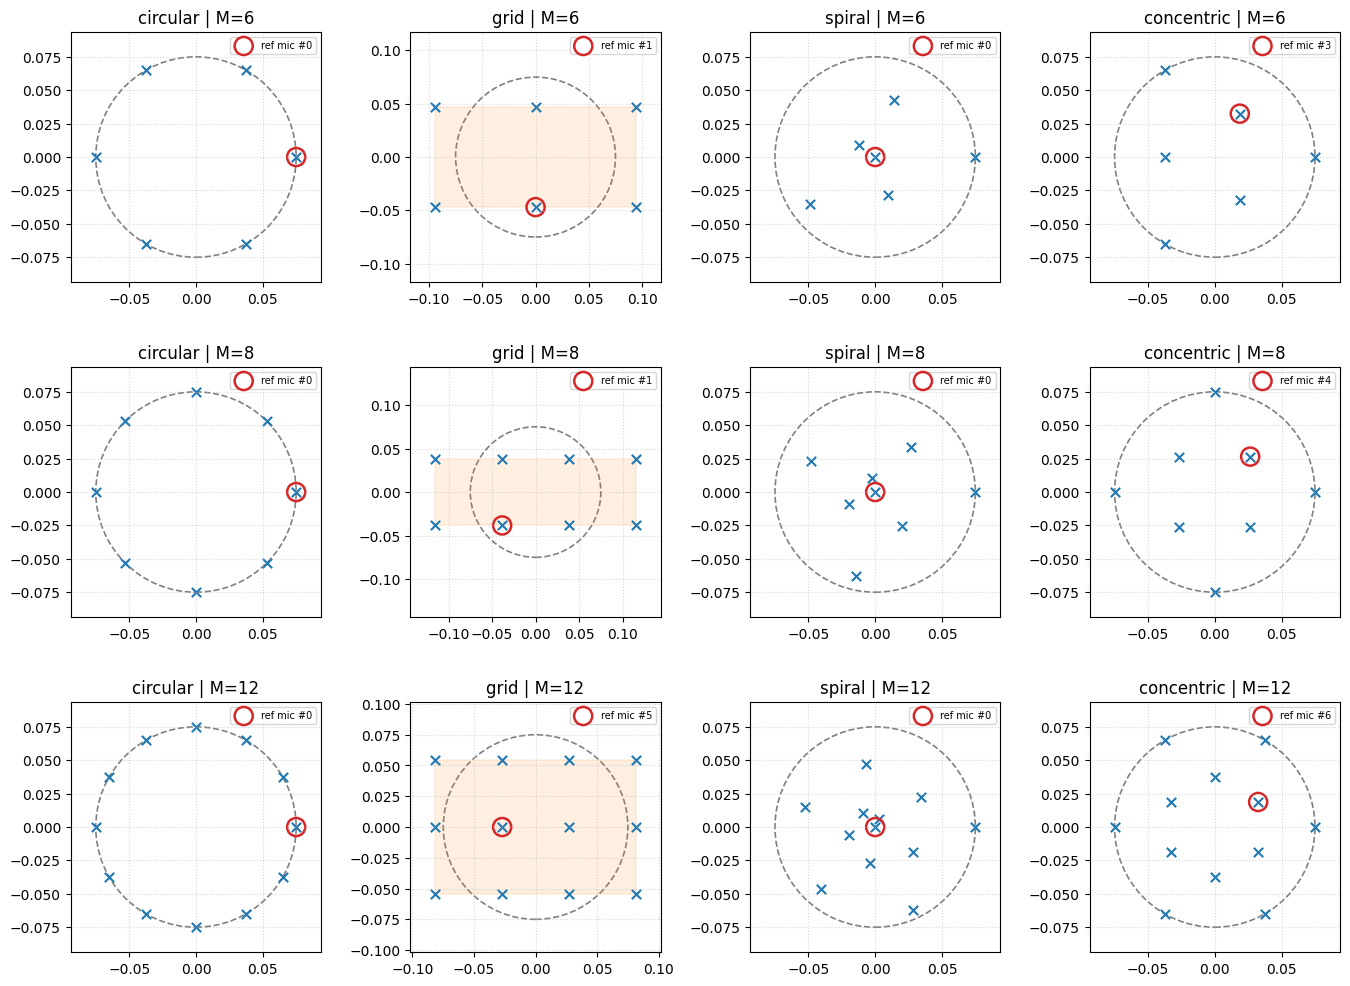

In [3]:
import matplotlib.patches as mpatches

C_SOUND = 343.0

# --- Tabla: que arreglo arma realmente el motor para cada (topologia, M) ---
rows = []
for M in M_LIST:
    for topo in TOPOLOGIES:
        c = generate_array_coords(topo, M, DIAMETER, **topo_kwargs_for(topo))[:, :2]
        dd = np.linalg.norm(c[:, None, :] - c[None, :, :], axis=-1)
        d_min = dd[dd > 0].min()
        span = c.max(axis=0) - c.min(axis=0)
        # Superficie ocupada: rectangulo abarcado (grilla) / disco de referencia
        # (topologias inscriptas, cuya area es la del circulo por construccion).
        area = span[0] * span[1] if topo == 'grid' else np.pi * (DIAMETER / 2.0) ** 2
        ref = select_reference_mic(c)
        d_ref = np.linalg.norm(c - c[ref], axis=1)     # distancias AL microfono de referencia
        rows.append({'M': M, 'topologia': topo, 'ref_mic': ref,
                     'dist_max_al_ref_cm': d_ref.max() * 100,
                     'dist_media_al_ref_cm': d_ref.mean() * 100,
                     'd_min_cm': d_min * 100, 'f_alias_kHz': C_SOUND / (2 * d_min) / 1000,
                     'apertura_max_cm': dd.max() * 100,
                     'span_cm': f'{span[0]*100:.1f} x {span[1]*100:.1f}',
                     'area_cm2': area * 1e4})
tab = pd.DataFrame(rows)
pd.set_option('display.float_format', lambda v: f'{v:.2f}')
print(f'A_ref (circulo D={DIAMETER*100:.0f} cm) = {A_REF*1e4:.1f} cm2\n')
print(tab.to_string(index=False))

# --- Galeria: una fila por M, una columna por topologia ---
fig, axes = plt.subplots(len(M_LIST), len(TOPOLOGIES),
                         figsize=(3.4 * len(TOPOLOGIES), 3.4 * len(M_LIST)))
axes = np.atleast_2d(axes)
for r, M in enumerate(M_LIST):
    for cix, topo in enumerate(TOPOLOGIES):
        ax = axes[r, cix]
        c = generate_array_coords(topo, M, DIAMETER, **topo_kwargs_for(topo))[:, :2]
        ref = select_reference_mic(c)
        ax.add_patch(mpatches.Circle((0, 0), DIAMETER / 2, ec='gray', fc='none', ls='--', lw=1.2))
        if topo == 'grid':   # rectangulo equivalente por area
            lo, hi = c.min(axis=0), c.max(axis=0)
            ax.add_patch(mpatches.Rectangle(lo, *(hi - lo), ec='tab:orange',
                                            fc='tab:orange', alpha=0.12, lw=1.2))
        ax.scatter(c[:, 0], c[:, 1], c='tab:blue', marker='x', s=45)
        ax.scatter(c[ref, 0], c[ref, 1], facecolors='none', edgecolors='tab:red', s=170,
                   lw=1.8, label=f'ref mic #{ref}')
        lim = max(DIAMETER / 2, np.abs(c).max()) * 1.25
        ax.set(xlim=(-lim, lim), ylim=(-lim, lim), title=f'{topo} | M={M}')
        ax.set_aspect('equal'); ax.grid(True, ls=':', alpha=0.5)
        ax.legend(loc='upper right', fontsize=7)
plt.tight_layout(); plt.show()


## Escena 3D — pre-vuelo

Reconstruye las posiciones **con la misma lógica que el motor** (`place_spherical` +
recorte de pared `max_distance_in_room` + override por-escena `source_specs`), para
**verificar antes de correr** dónde caen los `N_SCENES` targets (**toroide apoyado
sobre el piso**, concéntrico al arreglo) y las interferencias aleatorias. Vista **3D**
de la sala elegida con la caja de la sala, el bafle (piso), los micrófonos, la
superficie del toroide y las nubes de target/interferencia.


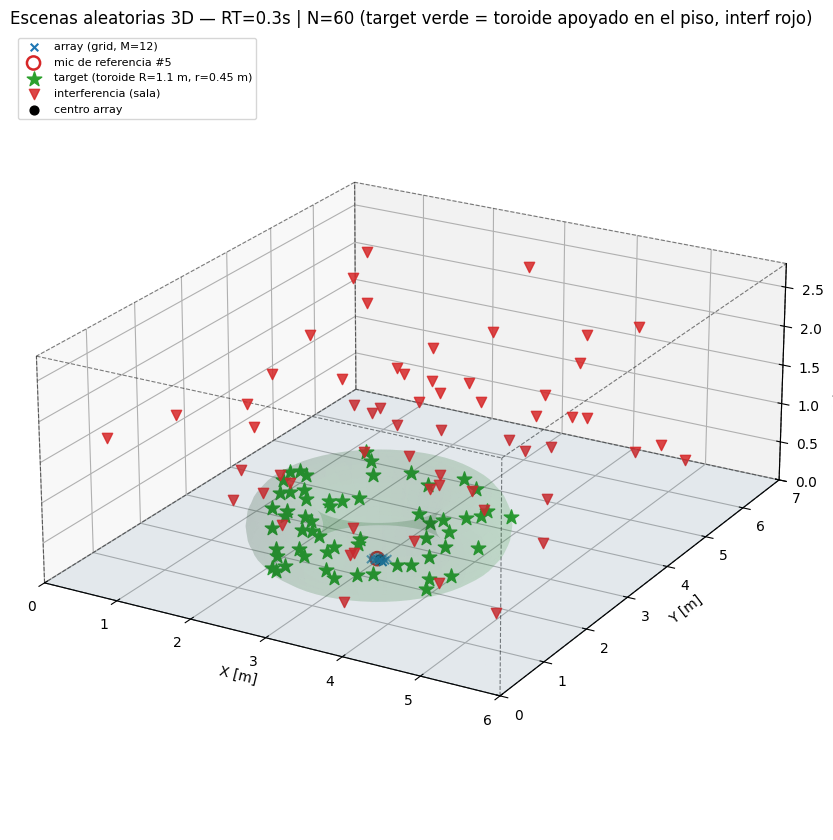

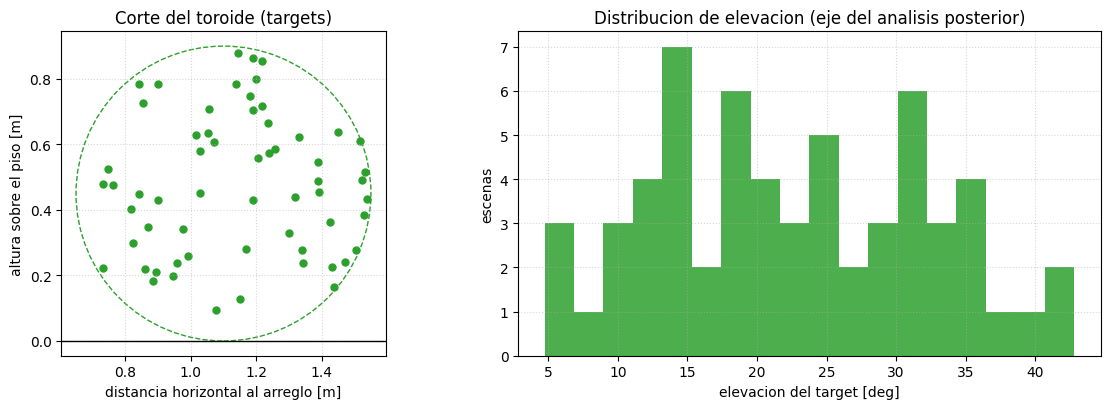

Target: distancia slant 0.76-1.63 m | altura 0.09-0.88 m sobre el piso | elevacion 4.7-42.8 deg (media 22.4)
Interf: distancia media al centro 2.79 m


In [4]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (habilita proj 3D)


def build_all_positions(rt60, topology='circular_center', M=None):
    """Reconstruye, tal cual el motor, las posiciones de TODAS las escenas para una
    sala: array (topologia dada), y para cada scene_id su target (source_specs) e
    interferencia (interf_scenarios), recortadas por pared. Devuelve
    (array_center, mic_coords, targets[N,3], interfs[N,3]).
    Usa COPIAS de room/ac para que NADA aguas abajo pueda mutar en sitio los dicts
    ROOM_PROFILES / ARRAY_CENTER_MAP."""
    M = M_LIST[-1] if M is None else M
    room = np.asarray(ROOM_PROFILES[rt60], dtype=float).copy()
    ac   = np.asarray(ARRAY_CENTER_MAP[rt60], dtype=float).copy()
    mic  = generate_array_coords(topology, M, DIAMETER, **topo_kwargs_for(topology)) + ac
    tgt, itf = [], []
    for sid in SCENE_IDS:
        t_az, t_el, t_d = SOURCE_SPECS[sid]
        t_d = min(t_d, max_distance_in_room(t_az, t_el, ac, room, WALL_MARGIN))
        tgt.append(place_spherical(t_az, t_el, t_d, ac))
        i_az, i_el, i_d = INTERF_SCENARIOS[sid][0]
        i_d = min(i_d, max_distance_in_room(i_az, i_el, ac, room, WALL_MARGIN))
        itf.append(place_spherical(i_az, i_el, i_d, ac))
    return ac, mic, np.array(tgt), np.array(itf)


def _draw_room_box(ax, room, **kw):
    x, y, z = room
    corners = np.array([[0, 0, 0], [x, 0, 0], [x, y, 0], [0, y, 0],
                        [0, 0, z], [x, 0, z], [x, y, z], [0, y, z]])
    edges = [(0, 1), (1, 2), (2, 3), (3, 0), (4, 5), (5, 6), (6, 7), (7, 4),
             (0, 4), (1, 5), (2, 6), (3, 7)]
    for a, b in edges:
        ax.plot(*zip(corners[a], corners[b]), **kw)


def _draw_torus(ax, center, r_major, r_tube, **kw):
    """Superficie del toroide (tubo tangente al piso) centrado en (cx, cy)."""
    u = np.linspace(0, 2 * np.pi, 60)      # alrededor del eje vertical
    v = np.linspace(0, 2 * np.pi, 24)      # alrededor del tubo
    U, V = np.meshgrid(u, v)
    X = center[0] + (r_major + r_tube * np.cos(V)) * np.sin(U)
    Y = center[1] + (r_major + r_tube * np.cos(V)) * np.cos(U)
    Z = r_tube + r_tube * np.sin(V)        # apoyado en el piso: z minimo = 0
    ax.plot_surface(X, Y, Z, **kw)


# Muestra la sala A (RT=0.3) con las N escenas aleatorias en 3D.
RT_SHOW = 0.30
TOPO_SHOW, M_SHOW = 'circular_center', M_LIST[-1]
ac, mic, tgt, itf = build_all_positions(RT_SHOW, TOPO_SHOW, M_SHOW)
ref_mic = select_reference_mic(mic)
room = np.asarray(ROOM_PROFILES[RT_SHOW], dtype=float).copy()  # COPIA: el plot no debe tocar el dict

fig = plt.figure(figsize=(11, 8.5))
axx = fig.add_subplot(111, projection='3d')
_draw_room_box(axx, room, color='k', ls='--', lw=0.8, alpha=0.5)
# bafle (piso, z=0) como una malla tenue
axx.plot_trisurf([0, room[0], room[0], 0], [0, 0, room[1], room[1]],
                 [0, 0, 0, 0], color='tab:blue', alpha=0.08)
_draw_torus(axx, ac, TORUS_R_MAJOR, TORUS_R_TUBE,
            color='tab:green', alpha=0.10, linewidth=0, antialiased=True)
axx.scatter(mic[:, 0], mic[:, 1], mic[:, 2], c='tab:blue', marker='x', s=30,
            label=f'array ({TOPO_SHOW}, M={M_SHOW})')
axx.scatter(*mic[ref_mic], facecolors='none', edgecolors='tab:red', s=90, lw=1.8,
            label=f'mic de referencia #{ref_mic}')
axx.scatter(tgt[:, 0], tgt[:, 1], tgt[:, 2], c='tab:green', marker='*', s=120,
            depthshade=False,
            label=f'target (toroide R={TORUS_R_MAJOR} m, r={TORUS_R_TUBE} m)')
axx.scatter(itf[:, 0], itf[:, 1], itf[:, 2], c='tab:red', marker='v', s=55,
            depthshade=False, alpha=0.85, label='interferencia (sala)')
axx.scatter(*ac, c='k', marker='o', s=40, label='centro array')

axx.set(xlabel='X [m]', ylabel='Y [m]', zlabel='Z (altura) [m]',
        xlim=(0, room[0]), ylim=(0, room[1]), zlim=(0, room[2]))
axx.set_title(f'Escenas aleatorias 3D — RT={RT_SHOW}s | N={N_SCENES} '
              f'(target verde = toroide apoyado en el piso, interf rojo)')
axx.view_init(elev=22, azim=-60)
axx.legend(loc='upper left', fontsize=8)
try:
    # IMPORTANTE: set_box_aspect MUTA el array que recibe -> pasar una tupla.
    axx.set_box_aspect(tuple(room))
except Exception:
    pass
plt.tight_layout(); plt.show()

# --- Corte vertical (distancia horizontal vs altura): se ve el toroide de perfil ---
r_h = np.hypot(tgt[:, 0] - ac[0], tgt[:, 1] - ac[1])
el_deg = np.rad2deg(np.arctan2(tgt[:, 2] - ac[2], r_h))
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.2))
a1.scatter(r_h, tgt[:, 2], c='tab:green', s=25)
a1.add_patch(plt.Circle((TORUS_R_MAJOR, TORUS_R_TUBE), TORUS_R_TUBE,
                        ec='tab:green', fc='none', ls='--'))
a1.axhline(0, color='k', lw=1)
a1.set(xlabel='distancia horizontal al arreglo [m]', ylabel='altura sobre el piso [m]',
       title='Corte del toroide (targets)')
a1.set_aspect('equal'); a1.grid(True, ls=':', alpha=0.5)
a2.hist(el_deg, bins=18, color='tab:green', alpha=0.85)
a2.set(xlabel='elevacion del target [deg]', ylabel='escenas',
       title='Distribucion de elevacion (eje del analisis posterior)')
a2.grid(True, ls=':', alpha=0.5)
plt.tight_layout(); plt.show()

r_tgt = np.linalg.norm(tgt - ac, axis=1)
print(f'Target: distancia slant {r_tgt.min():.2f}-{r_tgt.max():.2f} m '
      f'| altura {tgt[:,2].min():.2f}-{tgt[:,2].max():.2f} m sobre el piso '
      f'| elevacion {el_deg.min():.1f}-{el_deg.max():.1f} deg (media {el_deg.mean():.1f})')
print(f'Interf: distancia media al centro {np.linalg.norm(itf-ac, axis=1).mean():.2f} m')


### (Opcional) Cuántas posiciones recorta la pared
Cuenta, por sala, cuántos targets/interferencias piden más distancia de la que
permite la pared (el motor las recorta con `max_distance_in_room`). Con el arreglo
centrado, el toroide de targets (≤ 1.55 m de radio horizontal) entra completo y **no**
se recorta; solo alguna interferencia lejana puede recortarse — es esperable y no es un
error. También verifica que ninguna fuente quede bajo el piso ni pegada al arreglo.


In [5]:
# GUARD fail-fast: reconstruye cada posicion con el MISMO clamp del motor
# (max_distance_in_room) y aborta AQUI si algo cae fuera de la sala o se pega al
# arreglo, en vez de tirar el error a mitad del run largo. Ademas cuenta recortes.
def _clamped_point(az, el, d, ac, room):
    d = min(d, max_distance_in_room(az, el, ac, room, WALL_MARGIN))
    return place_spherical(az, el, d, ac), d

outside, collapsed, rows = [], [], []
for rt60, room in ROOM_PROFILES.items():
    ac = ARRAY_CENTER_MAP[rt60]
    n_tgt = n_itf = 0
    for sid in SCENE_IDS:
        for kind, (az, el, d0) in [('target', SOURCE_SPECS[sid]),
                                   ('interf', INTERF_SCENARIOS[sid][0])]:
            p, d = _clamped_point(az, el, d0, ac, room)
            if d < 0.05:                                        # se pego al arreglo
                collapsed.append((rt60, sid, kind, f'el={el:.1f}', round(float(d), 3)))
            if not (np.all(p > 0.0) and np.all(p < room)):      # estricto: dentro de la sala
                outside.append((rt60, sid, kind, np.round(p, 3).tolist()))
            if d < d0 - 1e-6:
                if kind == 'target': n_tgt += 1
                else:                n_itf += 1
    rows.append({'rt60': rt60, 'targets_recortados': n_tgt,
                 'interf_recortadas': n_itf, 'de_N': N_SCENES})

print(pd.DataFrame(rows).to_string(index=False))
assert not collapsed, (f"[ABORTADO] {len(collapsed)} fuente(s) recortadas a ~0 (pegadas al arreglo). "
                       f"Revisa que ROOM_PROFILES/ARRAY_CENTER_MAP no esten corruptos. Ej.: {collapsed[:5]}")
assert not outside, f"[ABORTADO] {len(outside)} posicion(es) FUERA de la sala: {outside[:5]}"

# El arreglo TAMBIEN tiene que entrar: la grilla equivalente por area puede ser mas
# ancha que el circulo de referencia, asi que se chequea con la geometria real.
# Solo en X e Y: en Z el arreglo esta DELIBERADAMENTE flush contra el piso
# (BAFFLE_HEIGHT), asi que no le aplica el margen de pared.
for rt60, room in ROOM_PROFILES.items():
    ac = ARRAY_CENTER_MAP[rt60]
    for topo in TOPOLOGIES:
        for M in M_LIST:
            mc = generate_array_coords(topo, M, DIAMETER, **topo_kwargs_for(topo)) + ac
            xy, room_xy = mc[:, :2], np.asarray(room)[:2]
            assert np.all(xy > WALL_MARGIN) and np.all(xy < room_xy - WALL_MARGIN), \
                f"[ABORTADO] arreglo {topo} M={M} fuera de la sala RT={rt60} (X/Y)"
            assert np.all(mc[:, 2] > 0) and np.all(mc[:, 2] < room[2]), \
                f"[ABORTADO] arreglo {topo} M={M} fuera de la sala RT={rt60} (Z)"

print(f'\n[OK] Las {2*N_SCENES*len(ROOM_PROFILES)} posiciones (target+interf x escena x sala) '
      f'caen DENTRO de la sala, ninguna pegada al arreglo, y los '
      f'{len(TOPOLOGIES)*len(M_LIST)} arreglos entran en las 3 salas. Seguro para correr.')


 rt60  targets_recortados  interf_recortadas  de_N
 0.30                   0                  0    60
 0.50                   0                  0    60
 0.80                   0                  0    60

[OK] Las 360 posiciones (target+interf x escena x sala) caen DENTRO de la sala, ninguna pegada al arreglo, y los 12 arreglos entran en las 3 salas. Seguro para correr.


## Run — barrido completo

> ⚠️ Runtime ∝ `3 salas × N_SCENES × 3 topologías × 3 valores de M` RIRs con ISM, con
> **un solo procesador** (`NM_MVDR`). Con `N_SCENES=60` son 1620 escenas físicas. Para
> probar rápido, bajá `N_SCENES` en la celda de Config (p. ej. 8), recortá `M_LIST` o
> `DURATION` a 10 s.
>
> **DTLN mono y post-filtro DTLN apagados**: `interpreter_1=interpreter_2=None` saltea
> el Node 4.5 (DTLN sobre el canal de referencia) y `apply_dtln_post=False` saltea el
> Node 6 (DTLN después del beamformer). Se ahorran dos pasadas del modelo por escena;
> `NM_MVDR` no se ve afectado porque levanta su propio intérprete para la máscara desde
> `dtln_model_path`.
>
> `ref_mic_mode='centroid'` hace que el baseline, las referencias y la proyección del
> beamformer usen **el mismo** canal — en `circular_center` es el micrófono central.
>
> Los resultados van a un `OUT_DIR` **propio** de esta fase, no pisan los datasets de
> las pruebas de `tests/array/`.


In [ ]:
# Dataset propio de esta fase: no pisa tests/array/dataset_out_* (sweep de topologias,
# grid-vs-powerlaw, circular-center) ni las corridas anteriores de Fase 3.
OUT_DIR = os.path.join(REPO_ROOT, 'tests/documentation_experiments/data/Fase_3/array_circcenter_nmmvdr')

base_config = {
    'geometry_mode': 'topology',
    'fs': 16000,
    'duration': DURATION,
    't_early': 0.050,
    'ray_tracing': RAY_TRACING,
    'snr_db': 60.0,
    'source_path': os.path.join(REPO_ROOT, 'tools/data/signals/p002_emo_adoration_sentences.wav'),
    'interf_paths': [
        os.path.join(REPO_ROOT, 'tools/data/signals/techno_gated commune.wav'),
    ],
    'dtln_model_path': os.path.join(SRC, 'dnn_denoise/models/model_quant_1.tflite'),
    'wpe_taps': 7, 'wpe_delay': 3, 'wpe_alpha': 0.9999,
    'wpe_stft_size': 512, 'wpe_stft_shift': 128,
    'stft_window': 512, 'stft_overlap': 384,
    # Opciones por topologia: la grilla se arma equivalente POR AREA (no inscripta).
    'topology_kwargs': TOPOLOGY_KWARGS,
    'eval_references': ['anechoic', 'early', 'reverberant'],
    # Microfono de referencia = centro geometrico del arreglo. Lo usan TANTO los
    # beamformers (punto de escucha del filtro de Souden / NM-MVDR) COMO las
    # metricas (baseline y referencias), para no mezclar dos canales distintos.
    'ref_mic_mode': REF_MIC_MODE,
    # --- Colocacion 3D (modo topology) ---
    'array_center_map': ARRAY_CENTER_MAP,
    'wall_margin': WALL_MARGIN,
    # Interferencia por-escena (1 por scene_id): {scene_id -> [(az, el, dist)]}.
    'interf_scenarios': INTERF_SCENARIOS,
    # Target por-escena (toroide): {scene_id -> (az, el, dist)}. Override del
    # angulo/distancia global.
    'source_specs': SOURCE_SPECS,
}

param_grid = {
    'topology': TOPOLOGIES,
    'M': M_LIST,
    'diameter': [DIAMETER],
    'rt60': list(ROOM_PROFILES),
    'interf_scenario': SCENE_IDS,   # cada scene_id = un par target/interf aleatorio
    'source_dist': [1.0],           # placeholder: source_specs (radio por-escena) lo sobre-escribe
    'mismatch_pos': [0.0],
    'isir_db': [ISIR_DB],
    'mismatch_gain': [0],
    'mismatch_phase': [0],
    'use_wpe': [False],
    'error_angle_deg': [0.0],
    'error_distance_m': [0.0],
}

# Unico procesador: NM_MVDR (mascara DTLN + Souden), el sistema real. Se saco
# SOUDEN_ORACLE_SCM: la pregunta de esta fase es que geometria le conviene al sistema
# implementable, no cuanto techo estadistico hay.
processors = {
    'NM_MVDR': NM_MVDR(),
}

df = run_grid_search(
    grid_params=param_grid,
    room_profiles=ROOM_PROFILES,
    processors=processors,
    scene_base_config=base_config,
    output_dir=OUT_DIR,
    # interpreter_1/2=None -> se saltea el DTLN mono (Node 4.5);
    # apply_dtln_post=False -> se saltea el post-filtro DTLN (Node 6).
    # Dos pasadas menos del modelo por escena. NM_MVDR no se entera: su mascara sale
    # de su propio interprete, cargado desde base_config['dtln_model_path'].
    interpreter_1=None, interpreter_2=None,
    save_catalog=SAVE_CATALOG,
    apply_dtln_post=False,
)
print('\n[*] Filas:', len(df), '| CSV:', os.path.join(OUT_DIR, 'ism_benchmark_metrics.csv'))


[*] t_early FIXED at 50.0 ms (decoupled from wpe_delay).
[*] Total experiments to run: 2160 per processor.


Running Benchmark:   0%|          | 0/2160 [00:00<?, ?exp/s]


--- Iteration 1/2160 | Config: {'topology': 'circular', 'M': 6, 'diameter': 0.15, 'rt60': 0.3, 'interf_scenario': 'sc00', 'source_dist': 1.0, 'mismatch_pos': 0.0, 'isir_db': 0, 'mismatch_gain': 0, 'mismatch_phase': 0, 'use_wpe': False, 'error_angle_deg': 0.0, 'error_distance_m': 0.0, 'source_path': '/home/matias/Documents/Tesis/Vision-Aided-Beamformer/tools/data/signals/p002_emo_adoration_sentences.wav'} ---
 -> [NODE 1|topology] Building 'circular' array (M=6, D=0.15 m) | room RT=0.3s | interf='sc00' | src_dist=1.0m; simulating RIRs (ISM)...
[Loader] Remuestreando de 48000 Hz a 16000 Hz...
[Loader] Audio corto, repitiendo en bucle para llenar duración...
[Loader] Remuestreando de 44100 Hz a 16000 Hz...


/home/matias/Documents/Tesis/Vision-Aided-Beamformer/src/utils/audio.py:32: WavFileWarning: Chunk (non-data) not understood, skipping it.
  fs_file, data = wavfile.read(filename)


[SimAcoustic] Built calibrated alpha<->RT60 map for room [6.  7.  2.8] (fs=16000, order=50).
[SimAcoustic] Mode: Calibrated Pure ISM (RT60 target=0.3s -> alpha=0.391, order=50)


...

Running Benchmark:   1%|          | 24/2160 [03:21<5:00:12,  8.43s/exp]

 -> [NODE 4] Bypassing WPE pre-processing...
   -> Processing with: DS (ErrAng: 0.0deg, ErrDist: 0.0m)...


Running Benchmark:   1%|          | 24/2160 [03:22<5:00:12,  8.43s/exp]

   -> Processing with: NM_MVDR (ErrAng: 0.0deg, ErrDist: 0.0m)...
 -> Computing DTLN mask (sharpen_exp=4.0) for ref channel 0...
Processing frame 1871 of 1872

Running Benchmark:   1%|          | 24/2160 [03:24<5:00:12,  8.43s/exp]

## Resultados — topología × M × escenas aleatorias

Ranking por `Delta_tot_*_early` (mejora vs. el **micrófono de referencia** crudo, que
ahora es el central), agregando por **mediana** sobre las `N_SCENES × 3 salas` escenas
aleatorias (robusta a outliers, p. ej. SIR enorme a RT bajo). Se desglosa por `M`, por
sala, y por **elevación del target** — el eje que peor discrimina un arreglo planar y
que el toroide barre de forma controlada.


In [ ]:
REF = 'early'
METRICS = ['STOI', 'PESQ', 'SIR', 'SDR']
topo_order = [t for t in ['circular_center', 'grid', 'concentric']
              if t in df['topology'].unique()]
PROCS = [p for p in ['NM_MVDR'] if p in df['processor'].unique()]

cols = ['topology', 'M', 'processor', 'rt60', 'interf_scenario', 'source_dist',
        'source_elevation_deg', 'source_azimuth_deg', 'source_slant_m', 'source_height_m',
        'interf_elevation_deg', 'ref_mic_idx'] + [f'Delta_tot_{m}_{REF}' for m in METRICS]
cols = [c for c in cols if c in df.columns]
view = df[cols].rename(columns={f'Delta_tot_{m}_{REF}': m for m in METRICS}).copy()
view['topology'] = pd.Categorical(view['topology'], categories=topo_order, ordered=True)

pd.set_option('display.float_format', lambda v: f'{v:+.3f}')
for proc in PROCS:
    print(f'\n===== {proc}: MEDIANA sobre TODAS las escenas y M (Delta_tot vs {REF}) =====')
    sub = view[view['processor'] == proc].groupby('topology', observed=True)[METRICS].median()
    print(sub.reindex(topo_order).to_string())


In [ ]:
# Desglose por CANTIDAD DE MICROFONOS: mediana por (topologia x M)
for proc in PROCS:
    print(f'\n===== {proc}: mediana por (topologia x M) =====')
    for metric in ['SIR', 'STOI']:
        piv = (view[view['processor'] == proc]
               .pivot_table(index='topology', columns='M', values=metric,
                            aggfunc='median', observed=True)
               .reindex(topo_order))
        print(f'\n-- {metric} --')
        print(piv.to_string())

# Barras: metrica mediana por topologia, una serie por M
fig, axes = plt.subplots(len(PROCS), 2, figsize=(13, 3.8 * len(PROCS)), squeeze=False)
for r, proc in enumerate(PROCS):
    for c, metric in enumerate(['SIR', 'STOI']):
        ax = axes[r][c]
        piv = (view[view['processor'] == proc]
               .pivot_table(index='topology', columns='M', values=metric,
                            aggfunc='median', observed=True)
               .reindex(topo_order))
        piv.plot(kind='bar', ax=ax, rot=20)
        ax.set_title(f'{proc}: {metric} mediano por M (Delta_tot vs {REF})')
        ax.set_ylabel(f'Delta {metric}'); ax.axhline(0, color='k', lw=0.8)
        ax.grid(True, axis='y', ls=':', alpha=0.5); ax.legend(title='M', fontsize=8)
plt.tight_layout(); plt.show()


In [ ]:
# ================== TENDENCIA vs ELEVACION DEL TARGET ==================
# El toroide barre elevaciones de ~2 a ~45 deg: este es el eje que peor discrimina
# un arreglo PLANAR (todas las topologias son 2D), asi que es donde se espera ver
# la diferencia entre ellas. Se agrupa en bins de elevacion y se toma la MEDIANA.
EL_EDGES = np.arange(0, 50, 7.5)     # bins de 7.5 deg
view['el_bin'] = pd.cut(view['source_elevation_deg'], EL_EDGES)
view['el_mid'] = view['el_bin'].apply(lambda b: b.mid if pd.notna(b) else np.nan).astype(float)

METRIC_EL = ['SIR', 'STOI', 'PESQ']
fig, axes = plt.subplots(len(PROCS), len(METRIC_EL),
                         figsize=(4.6 * len(METRIC_EL), 3.6 * len(PROCS)), squeeze=False)
for r, proc in enumerate(PROCS):
    sub = view[view['processor'] == proc]
    for c, metric in enumerate(METRIC_EL):
        ax = axes[r][c]
        piv = sub.pivot_table(index='el_mid', columns='topology', values=metric,
                              aggfunc='median', observed=True)
        for topo in topo_order:
            if topo in piv.columns:
                ax.plot(piv.index, piv[topo], marker='o', label=topo)
        ax.axhline(0, color='k', lw=0.8)
        ax.set(xlabel='elevacion del target [deg]', ylabel=f'Delta {metric}',
               title=f'{proc}: {metric} vs elevacion')
        ax.grid(True, ls=':', alpha=0.5)
        if c == 0:
            ax.legend(fontsize=7)
plt.tight_layout(); plt.show()

# Mismo eje pero por M (agregando topologias): cuanto compra sumar microfonos
# cuando la fuente se levanta del plano del arreglo.
fig, axes = plt.subplots(1, len(PROCS), figsize=(4.8 * len(PROCS), 3.8), squeeze=False)
for c, proc in enumerate(PROCS):
    ax = axes[0][c]
    piv = (view[view['processor'] == proc]
           .pivot_table(index='el_mid', columns='M', values='SIR',
                        aggfunc='median', observed=True))
    for M in piv.columns:
        ax.plot(piv.index, piv[M], marker='o', label=f'M={M}')
    ax.axhline(0, color='k', lw=0.8)
    ax.set(xlabel='elevacion del target [deg]', ylabel='Delta SIR',
           title=f'{proc}: SIR vs elevacion, por M')
    ax.grid(True, ls=':', alpha=0.5); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

print('Escenas por bin de elevacion (por procesador/topologia/M se reparten):')
print(view.groupby('el_bin', observed=True).size().to_string())


In [ ]:
# Desglose por sala (RT60): SIR mediano por (topologia x rt60) — robustez por reverb
for proc in PROCS:
    print(f'\n===== {proc}: SIR MEDIANO por (topologia x rt60) =====')
    piv = (view[view['processor'] == proc]
           .pivot_table(index='topology', columns='rt60', values='SIR',
                        aggfunc='median', observed=True)
           .reindex(topo_order))
    print(piv.to_string())


In [ ]:
# Barras: PESQ y STOI MEDIANOS por topologia y algoritmo
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for ax, metric in zip(axes, ['PESQ', 'STOI']):
    piv = view.pivot_table(index='topology', columns='processor', values=metric,
                           aggfunc='median', observed=True).reindex(topo_order)
    piv.plot(kind='bar', ax=ax, rot=20)
    ax.set_title(f'{metric} mediano (Delta_tot vs {REF})')
    ax.set_ylabel(f'Delta {metric}'); ax.axhline(0, color='k', lw=0.8)
    ax.grid(True, axis='y', ls=':', alpha=0.5)
plt.tight_layout(); plt.show()


In [ ]:
# Dispersion escena-a-escena: boxplot de SIR por topologia (una caja = N_SCENES*3 salas*M)
# La MEDIANA rankea, pero el ancho de la caja dice que topologia es mas CONSISTENTE.
fig, axes = plt.subplots(1, len(PROCS), figsize=(6.0 * len(PROCS), 4.5), sharey=True,
                         squeeze=False)
for ax, proc in zip(axes[0], PROCS):
    data = [view[(view['processor'] == proc) & (view['topology'] == t)]['SIR'].dropna().values
            for t in topo_order]
    ax.boxplot(data, tick_labels=topo_order, showmeans=True)
    ax.set_title(f'{proc}: distribucion de SIR (Delta_tot vs {REF})')
    ax.set_ylabel('Delta SIR'); ax.axhline(0, color='k', lw=0.8)
    ax.grid(True, axis='y', ls=':', alpha=0.5); ax.tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.show()
